# 03 — Modeling (temporal validation)

Predict `cycle_days` using only information that would reasonably be known **on the day construction starts**.

This notebook:

- prepares features from the cleaned training extract
- uses a **maturity-based** temporal split (train 2021–2023, validate Jan–Jun 2024)
- holds out starts after 2024-06-30 from fitting, early stopping, baselines, and model selection
- fits two baselines and three CatBoost variants (core without `start_year` is the primary candidate)
- stops after validation results for model selection
- adds a separate risk-adjusted site-manager comparison (not used to pick the model)

It does **not** retrain on the full extract, does **not** write `predictions.csv`, and does **not** modify any cleaned CSV.


In [1]:
from pathlib import Path
import hashlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from IPython.display import Markdown, display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 110)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

CANDIDATES = [
    Path("data/build_history_train.csv"),
    Path("data/processed/build_history_train.csv"),
]
TRAIN_PATH = next((p for p in CANDIDATES if p.exists()), None)
assert TRAIN_PATH is not None, "Missing build_history_train.csv (checked data/ and data/processed/)."
RAW_HIST_PATH = Path("data/build_history.csv")


def file_sha256(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


RAW_HASH = file_sha256(TRAIN_PATH)
df_raw = pd.read_csv(TRAIN_PATH)
print("loaded", TRAIN_PATH, "shape", df_raw.shape)
print("sha256", RAW_HASH)
assert df_raw["cycle_days"].notna().all()
assert (df_raw["cycle_days"] > 0).all()


loaded data\processed\build_history_train.csv shape (4077, 33)
sha256 0dc0c22b16fabecefa4523abd8ea9df352165801ee8e94fdc765659421e1ec20


## 1. Excluded fields

These columns are not model inputs. `home_id` is kept on the side for later scoring output only.


In [2]:
exclusion = pd.DataFrame([
    ["home_id", "Identifier only; preserve for later prediction output, not as a feature"],
    ["lot_number", "Identifier-like; reused across communities and can overfit"],
    ["plan_name", "One-to-one with plan_code; keep plan_code only"],
    ["sale_date", "Replaced by sale-recorded flag and days-from-sale"],
    ["permit_application_date", "Replaced by permit processing days"],
    ["permit_issue_date", "Replaced by permit processing days and permit-to-start days"],
    ["construction_start_date", "Replaced by start year/month/quarter (used only to split and derive)"],
    ["construction_end_date", "Target leakage (endpoint of cycle_days)"],
    ["final_inspection_date", "Not available on the construction start date"],
    ["change_order_count", "Accumulates after construction begins"],
    ["trade_invoice_total", "Running construction cost; leakage and missing at start for scoring homes"],
    ["construction_status", "Post-start / constant Complete in this training extract"],
    ["data_source", "Constant BUILDPRO_EXPORT"],
    ["train_eligible", "Cleaning metadata"],
    ["exclude_reason", "Cleaning metadata"],
    ["cycle_days", "Prediction target, not an input"],
], columns=["field", "reason"])
display(exclusion)
EXCLUDED = set(exclusion.field)


,field,reason
0,home_id,"Identifier only; preserve for later prediction output, not as a feature"
1,lot_number,Identifier-like; reused across communities and can overfit
2,plan_name,One-to-one with plan_code; keep plan_code only
3,sale_date,Replaced by sale-recorded flag and days-from-sale
4,permit_application_date,Replaced by permit processing days
5,permit_issue_date,Replaced by permit processing days and permit-to-start days
6,construction_start_date,Replaced by start year/month/quarter (used only to split and derive)
7,construction_end_date,Target leakage (endpoint of cycle_days)
8,final_inspection_date,Not available on the construction start date
9,change_order_count,Accumulates after construction begins


## 2. Feature preparation

Core categoricals and numerics are those judged available at start. Date columns are parsed only to build start-time derived fields, then dropped from the model matrix.

`selected_options_value` is **not** in the core set. It is added only in an expanded sensitivity model.

`start_year` is still derived (it is known at start) but is **withheld from the primary model**. A later comparison checks whether it helps on a mature validation window, rather than treating its earlier importance as a reason to keep it.


In [3]:
CAT_CORE = [
    "community", "metro", "permit_authority", "plan_code", "product_line",
    "basement_type", "lot_type", "site_manager", "is_spec_home",
]
NUM_CORE = [
    "beds", "baths", "half_baths", "sqft", "stories", "garage_size", "lot_size_sqft",
]
DERIVED_NUM = [
    "start_year", "start_month", "start_quarter",
    "permit_processing_days", "permit_to_start_days",
    "sale_recorded_before_start", "days_sale_to_start",
]
AMBIGUOUS_NUM = ["selected_options_value"]
DATE_COLS = [
    "sale_date", "permit_application_date", "permit_issue_date", "construction_start_date",
]

work = df_raw.copy()
for c in DATE_COLS + ["construction_end_date", "final_inspection_date"]:
    if c in work.columns:
        work[c] = pd.to_datetime(work[c], errors="coerce")

work["start_year"] = work["construction_start_date"].dt.year.astype("int64")
work["start_month"] = work["construction_start_date"].dt.month.astype("int64")
work["start_quarter"] = work["construction_start_date"].dt.quarter.astype("int64")
work["permit_processing_days"] = (
    work["permit_issue_date"] - work["permit_application_date"]
).dt.days
work["permit_to_start_days"] = (
    work["construction_start_date"] - work["permit_issue_date"]
).dt.days

sale_ok = work["sale_date"].notna() & (work["sale_date"] <= work["construction_start_date"])
work["sale_recorded_before_start"] = sale_ok.astype("int64")
work["days_sale_to_start"] = np.where(
    sale_ok, (work["construction_start_date"] - work["sale_date"]).dt.days, np.nan
)

# Categoricals: missing -> Unknown, always string. No statistics from validation.
work["is_spec_home"] = work["is_spec_home"].map({True: "True", False: "False"}).fillna(
    work["is_spec_home"].astype(str)
)
for c in CAT_CORE:
    work[c] = work[c].replace({"": np.nan}).where(work[c].notna(), "Unknown").astype(str)
    work.loc[work[c].str.lower().isin(["nan", "none", "<na>"]), c] = "Unknown"

CORE_FEATURES = CAT_CORE + NUM_CORE + DERIVED_NUM
EXPANDED_FEATURES = CORE_FEATURES + AMBIGUOUS_NUM
FEATURES_CORE_NO_YEAR = [f for f in CORE_FEATURES if f != "start_year"]
FEATURES_CORE_WITH_YEAR = list(CORE_FEATURES)
FEATURES_EXPANDED_NO_YEAR = FEATURES_CORE_NO_YEAR + AMBIGUOUS_NUM

print("core features (all derived, including start_year):", CORE_FEATURES)
print("primary model omits start_year:", FEATURES_CORE_NO_YEAR)
print("expanded (no start_year) adds:", AMBIGUOUS_NUM)
print("derived numeric describe:")
display(work[DERIVED_NUM].describe().T)
print("sale_recorded_before_start rate:", work.sale_recorded_before_start.mean())
print("days_sale_to_start missing (no valid pre-start sale):", int(work.days_sale_to_start.isna().sum()))


core features (all derived, including start_year): ['community', 'metro', 'permit_authority', 'plan_code', 'product_line', 'basement_type', 'lot_type', 'site_manager', 'is_spec_home', 'beds', 'baths', 'half_baths', 'sqft', 'stories', 'garage_size', 'lot_size_sqft', 'start_year', 'start_month', 'start_quarter', 'permit_processing_days', 'permit_to_start_days', 'sale_recorded_before_start', 'days_sale_to_start']
primary model omits start_year: ['community', 'metro', 'permit_authority', 'plan_code', 'product_line', 'basement_type', 'lot_type', 'site_manager', 'is_spec_home', 'beds', 'baths', 'half_baths', 'sqft', 'stories', 'garage_size', 'lot_size_sqft', 'start_month', 'start_quarter', 'permit_processing_days', 'permit_to_start_days', 'sale_recorded_before_start', 'days_sale_to_start']
expanded (no start_year) adds: ['selected_options_value']
derived numeric describe:


,count,mean,std,min,25%,50%,75%,max
start_year,"4,077.00","2,022.70",1.17,"2,021.00","2,022.00","2,023.00","2,024.00","2,025.00"
start_month,"4,077.00",6.45,3.38,1.00,4.00,6.00,9.00,12.00
start_quarter,"4,077.00",2.49,1.10,1.00,2.00,2.00,3.00,4.00
permit_processing_days,"4,077.00",44.52,28.76,6.00,23.00,39.00,59.00,210.00
permit_to_start_days,"4,077.00",32.28,16.13,5.00,18.00,32.00,46.00,60.00
sale_recorded_before_start,"4,077.00",0.66,0.47,0.00,0.00,1.00,1.00,1.00
days_sale_to_start,"2,683.00",93.26,40.23,25.00,58.00,92.00,127.00,164.00


sale_recorded_before_start rate: 0.6580819229825853
days_sale_to_start missing (no valid pre-start sale): 1394


Numeric missings stay as `NaN` (CatBoost handles them). Categorical missings are `"Unknown"`. No target-based imputation and no validation-set preprocessing.


In [4]:
print("numeric NaNs in core numerics:")
display(work[NUM_CORE + DERIVED_NUM].isna().sum().to_frame("n_nan"))
print("categorical levels:")
display(pd.Series({c: work[c].nunique() for c in CAT_CORE}, name="n_levels").to_frame())

for feats in (FEATURES_CORE_NO_YEAR, FEATURES_CORE_WITH_YEAR, FEATURES_EXPANDED_NO_YEAR):
    leak = sorted(set(feats) & EXCLUDED)
    assert not leak, leak
assert "plan_name" not in FEATURES_CORE_NO_YEAR
assert "start_year" not in FEATURES_CORE_NO_YEAR
assert "start_year" in FEATURES_CORE_WITH_YEAR
assert "selected_options_value" not in FEATURES_CORE_NO_YEAR
assert "selected_options_value" not in FEATURES_CORE_WITH_YEAR
assert "selected_options_value" in FEATURES_EXPANDED_NO_YEAR
assert "start_year" not in FEATURES_EXPANDED_NO_YEAR
print("assertions passed: excluded/leakage fields are not in any model feature list")


numeric NaNs in core numerics:


,n_nan
beds,123
baths,0
half_baths,0
sqft,0
stories,0
garage_size,0
lot_size_sqft,88
start_year,0
start_month,0
start_quarter,0


categorical levels:


,n_levels
community,14
metro,3
permit_authority,7
plan_code,16
product_line,3
basement_type,3
lot_type,3
site_manager,18
is_spec_home,2


assertions passed: excluded/leakage fields are not in any model feature list


## 3. Maturity-based temporal split

The cleaned training CSV contains **only completed** builds. Homes that started late in 2024 or in 2025 had less calendar time to finish before the apparent extract snapshot of **2025-07-31**. Completed rows in that recent window therefore over-represent faster jobs; slower jobs may still have been in progress and never entered this file. That is right-censoring / completion-selection bias, not evidence that construction became faster.

The cutoff is about **label maturity** (enough elapsed time for a typical cycle to be observed), not an assumption that cycle times changed in a given year.

| Cohort | Start dates | Role |
|---|---|---|
| Training | 2021-01-01 through 2023-12-31 | Fit baselines and CatBoost |
| Validation | 2024-01-01 through 2024-06-30 inclusive | Early stopping, metrics, model comparison |
| Recent excluded | after 2024-06-30 (includes all 2025) | Reporting only; not used to fit, stop, or select |

Recent rows stay in a separate DataFrame. They are not dropped from the cleaned CSV.


In [5]:
TRAIN_START = pd.Timestamp("2021-01-01")
TRAIN_END = pd.Timestamp("2023-12-31")
VAL_START = pd.Timestamp("2024-01-01")
VAL_END = pd.Timestamp("2024-06-30")

work = work.sort_values(["construction_start_date", "home_id"], kind="mergesort").reset_index(drop=True)

train = work[
    (work["construction_start_date"] >= TRAIN_START)
    & (work["construction_start_date"] <= TRAIN_END)
].copy()
val = work[
    (work["construction_start_date"] >= VAL_START)
    & (work["construction_start_date"] <= VAL_END)
].copy()
recent_excluded = work[work["construction_start_date"] > VAL_END].copy()


def cohort_summary(frame, name):
    return {
        "cohort": name,
        "row_count": len(frame),
        "start_min": frame["construction_start_date"].min(),
        "start_max": frame["construction_start_date"].max(),
        "end_min": frame["construction_end_date"].min(),
        "end_max": frame["construction_end_date"].max(),
        "cycle_days_mean": frame["cycle_days"].mean(),
        "cycle_days_median": frame["cycle_days"].median(),
        "cycle_days_min": frame["cycle_days"].min(),
        "cycle_days_max": frame["cycle_days"].max(),
    }


cohorts = pd.DataFrame([
    cohort_summary(train, "Training (2021-01-01 to 2023-12-31)"),
    cohort_summary(val, "Validation (2024-01-01 to 2024-06-30)"),
    cohort_summary(recent_excluded, "Recent excluded (after 2024-06-30)"),
])
display(cohorts)

# --- assertions: who is used for fitting / stopping / evaluation ---
assert train["construction_start_date"].dt.year.isin([2021, 2022, 2023]).all()
assert (train["construction_start_date"] >= TRAIN_START).all()
assert (train["construction_start_date"] <= TRAIN_END).all()
assert (val["construction_start_date"].dt.year == 2024).all()
assert (val["construction_start_date"].dt.month.between(1, 6)).all()
assert (val["construction_start_date"] >= VAL_START).all()
assert (val["construction_start_date"] <= VAL_END).all()
assert val["construction_start_date"].min() > train["construction_start_date"].max()
assert (recent_excluded["construction_start_date"] > VAL_END).all()
assert set(train.index).isdisjoint(val.index)
assert set(train.index).isdisjoint(recent_excluded.index)
assert set(val.index).isdisjoint(recent_excluded.index)
assert len(train) + len(val) + len(recent_excluded) == len(work)
print("split assertions passed")
print("recent excluded is held out from train/val:", len(recent_excluded), "rows")

# Read-only completion diagnostic from the original extract, if present.
if RAW_HIST_PATH.exists():
    raw_hist = pd.read_csv(RAW_HIST_PATH)
    raw_hist["construction_start_date"] = pd.to_datetime(
        raw_hist["construction_start_date"], errors="coerce"
    )
    raw_hist["start_year_month"] = raw_hist["construction_start_date"].dt.to_period("M").astype(str)
    diag = (
        raw_hist.groupby("start_year_month")
        .agg(
            n=("construction_status", "size"),
            n_complete=("construction_status", lambda s: int(s.eq("Complete").sum())),
            n_in_progress=("construction_status", lambda s: int(s.eq("In Progress").sum())),
        )
        .reset_index()
    )
    diag["completion_rate"] = diag["n_complete"] / diag["n"]
    print("Completion rates by start year-month from data/build_history.csv (read-only; not used for training):")
    display(diag)
else:
    print(
        "data/build_history.csv is unavailable. Completion rates cannot be calculated from "
        "build_history_train.csv because that file already contains only eligible completed builds."
    )


,cohort,row_count,start_min,start_max,end_min,end_max,cycle_days_mean,cycle_days_median,cycle_days_min,cycle_days_max
0,Training (2021-01-01 to 2023-12-31),2839,2021-01-04,2023-12-31,2021-05-12,2024-12-10,199.27,190.00,72,622
1,Validation (2024-01-01 to 2024-06-30),530,2024-01-01,2024-06-28,2024-04-24,2025-05-17,172.62,162.00,76,362
2,Recent excluded (after 2024-06-30),708,2024-07-01,2025-05-20,2024-09-26,2025-07-31,151.68,147.00,65,324


split assertions passed
recent excluded is held out from train/val: 708 rows
Completion rates by start year-month from data/build_history.csv (read-only; not used for training):


,start_year_month,n,n_complete,n_in_progress,completion_rate
0,2021-01,45,45,0,1.00
1,2021-02,64,64,0,1.00
2,2021-03,62,62,0,1.00
3,2021-04,70,70,0,1.00
4,2021-05,60,60,0,1.00
5,2021-06,88,88,0,1.00
6,2021-07,73,73,0,1.00
7,2021-08,82,82,0,1.00
8,2021-09,86,86,0,1.00
9,2021-10,70,70,0,1.00


## 4. Baselines (training targets only)

**Global-average:** predict the **2021–2023 training** mean `cycle_days` for every validation row.

**Floor-plan-average:** **2021–2023 training** mean `cycle_days` by `plan_code`. Unseen plan codes fall back to that same training global mean.

Neither baseline uses the validation target, the recent excluded cohort, or any post-2023 start.


In [6]:
y_train = train["cycle_days"].astype(float)
y_val = val["cycle_days"].astype(float)

global_mean = float(y_train.mean())
plan_means = train.groupby("plan_code")["cycle_days"].mean()
pred_global = np.full(len(val), global_mean, dtype=float)
pred_plan = val["plan_code"].map(plan_means).astype(float).fillna(global_mean).to_numpy()

print("training global mean cycle_days:", round(global_mean, 3))
print("plan codes in train:", plan_means.size, "| unseen in validation:",
      int((~val.plan_code.isin(plan_means.index)).sum()))
print("rows using global fallback on plan baseline:", int(np.isnan(val["plan_code"].map(plan_means).astype(float)).sum()))

assert train["construction_start_date"].max() <= TRAIN_END
assert val["construction_start_date"].max() <= VAL_END
assert (recent_excluded["construction_start_date"] > VAL_END).all()
assert abs(global_mean - float(train["cycle_days"].mean())) < 1e-12
print("baseline assertions passed: means come only from the 2021-2023 training cohort")


training global mean cycle_days: 199.266
plan codes in train: 16 | unseen in validation: 0
rows using global fallback on plan baseline: 0
baseline assertions passed: means come only from the 2021-2023 training cohort


## 5. CatBoost models

All three variants share the same hyperparameters (unchanged; not searched against validation):

| Parameter | Value | Why |
|---|---|---|
| `loss_function` | RMSE | penalizes large day-errors during fitting |
| `eval_metric` | MAE | matches the primary reporting metric |
| `depth` | 6 | conservative for ~4,000 rows |
| `learning_rate` | 0.05 | moderate; early stopping can cut trees |
| `iterations` | 2000 | upper bound; early stopping ends the run |
| `early_stopping_rounds` | 80 | uses the **Jan–Jun 2024** validation set only as a stop signal |
| `random_seed` | 42 | reproducibility |
| `allow_writing_files` | False | no CatBoost artifact files |

Categoricals are passed as strings to CatBoost native handling (no one-hot encoding).

1. **CatBoost core without `start_year`** — primary candidate (available-at-start fields, omitting calendar year)
2. **CatBoost core with `start_year`** — sensitivity: does year help on this *mature* window, or was it mostly snapshot bias?
3. **CatBoost expanded without `start_year`** — core (no year) plus `selected_options_value`

Do **not** keep `start_year` just because it was important on the old 80/20 split. Do **not** adopt the expanded model just because validation MAE is lower. Use expanded only if the business confirms `selected_options_value` is an as-of-start figure.

Early stopping uses only the January–June 2024 validation cohort. The recent excluded rows are not in `eval_set`.


In [7]:
def make_xy(frame, feature_list):
    X = frame.loc[:, feature_list].copy()
    y = frame["cycle_days"].astype(float)
    cat_in = [c for c in feature_list if c in CAT_CORE]
    for c in cat_in:
        X[c] = X[c].astype(str)
    return X, y, cat_in


def metrics(y_true, y_pred, label):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "model": label,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
    }


CATBOOST_PARAMS = dict(
    loss_function="RMSE",
    eval_metric="MAE",
    random_seed=RANDOM_SEED,
    depth=6,
    learning_rate=0.05,
    iterations=2000,
    l2_leaf_reg=3.0,
    verbose=False,
    allow_writing_files=False,
    od_type="Iter",
    od_wait=80,
    use_best_model=True,
)


def fit_catboost(feature_list, label):
    X_tr, y_tr, cat_in = make_xy(train, feature_list)
    X_va, y_va, _ = make_xy(val, feature_list)
    assert set(X_tr.columns).isdisjoint(EXCLUDED)
    assert set(X_va.columns).isdisjoint(EXCLUDED)
    train_pool = Pool(X_tr, y_tr, cat_features=cat_in)
    val_pool = Pool(X_va, y_va, cat_features=cat_in)
    model = CatBoostRegressor(**CATBOOST_PARAMS)
    model.fit(train_pool, eval_set=val_pool, verbose=False)
    pred = model.predict(val_pool)
    info = metrics(y_va, pred, label)
    info["best_iteration"] = int(model.get_best_iteration() or model.tree_count_ - 1)
    info["tree_count"] = int(model.tree_count_)
    print(f"{label}: best_iteration={info['best_iteration']} tree_count={info['tree_count']}")
    return model, pred, info, X_tr.columns.tolist()


def _assert_fit_frames():
    assert train["construction_start_date"].max() <= TRAIN_END
    assert val["construction_start_date"].min() >= VAL_START
    assert val["construction_start_date"].max() <= VAL_END
    assert not (train["construction_start_date"] > VAL_END).any()
    assert not (val["construction_start_date"] > VAL_END).any()


_assert_fit_frames()
model_core, pred_core, info_core, cols_core = fit_catboost(
    FEATURES_CORE_NO_YEAR, "CatBoost core (no start_year)"
)
model_core_year, pred_core_year, info_core_year, cols_core_year = fit_catboost(
    FEATURES_CORE_WITH_YEAR, "CatBoost core (with start_year)"
)
model_exp, pred_exp, info_exp, cols_exp = fit_catboost(
    FEATURES_EXPANDED_NO_YEAR, "CatBoost expanded (no start_year + selected_options_value)"
)

print("primary core columns:", len(cols_core), "| with start_year:", len(cols_core_year), "| expanded no year:", len(cols_exp))
print("start_year in primary / with-year / expanded:", "start_year" in cols_core, "start_year" in cols_core_year, "start_year" in cols_exp)


CatBoost core (no start_year): best_iteration=158 tree_count=159


CatBoost core (with start_year): best_iteration=91 tree_count=92


CatBoost expanded (no start_year + selected_options_value): best_iteration=180 tree_count=181
primary core columns: 22 | with start_year: 23 | expanded no year: 23
start_year in primary / with-year / expanded: False True False


## 6. Validation comparison

MAE is the primary metric (typical error in days). RMSE penalizes large misses. R² is a diagnostic only.


In [8]:
rows = [
    metrics(y_val, pred_global, "Global-average baseline"),
    metrics(y_val, pred_plan, "Floor-plan-average baseline"),
    info_core,
    info_core_year,
    info_exp,
]
cmp = pd.DataFrame(rows)
base_g = cmp.loc[cmp.model.eq("Global-average baseline"), "MAE"].iloc[0]
base_p = cmp.loc[cmp.model.eq("Floor-plan-average baseline"), "MAE"].iloc[0]
cmp["MAE_improvement_vs_global_pct"] = (base_g - cmp["MAE"]) / base_g * 100
cmp["MAE_improvement_vs_plan_pct"] = (base_p - cmp["MAE"]) / base_p * 100
display(cmp)

assert set(cols_core).isdisjoint(EXCLUDED)
assert set(cols_core_year).isdisjoint(EXCLUDED)
assert set(cols_exp).isdisjoint(EXCLUDED)
assert "start_year" not in cols_core
assert "start_year" in cols_core_year
assert "start_year" not in cols_exp
assert "selected_options_value" not in cols_core
assert "selected_options_value" not in cols_core_year
assert "selected_options_value" in cols_exp
assert val["construction_start_date"].max() <= VAL_END
print("feature-matrix and evaluation-window assertions passed")
print("validation rows used for metrics:", len(val), "| recent excluded unused:", len(recent_excluded))


,model,MAE,RMSE,R2,best_iteration,tree_count,MAE_improvement_vs_global_pct,MAE_improvement_vs_plan_pct
0,Global-average baseline,50.73,60.03,-0.25,NaN,NaN,0.00,-37.83
1,Floor-plan-average baseline,36.81,44.83,0.31,NaN,NaN,27.45,0.00
2,CatBoost core (no start_year),33.20,39.99,0.45,158.00,159.00,34.56,9.81
3,CatBoost core (with start_year),35.49,42.22,0.38,91.00,92.00,30.04,3.57
4,CatBoost expanded (no start_year + selected_options_value),31.71,38.72,0.48,180.00,181.00,37.50,13.86


feature-matrix and evaluation-window assertions passed
validation rows used for metrics: 530 | recent excluded unused: 708


## 7. Plots and error patterns

The **primary candidate** for plots and grouped errors is **CatBoost core without `start_year`**. The with-year and expanded models are sensitivity checks only.


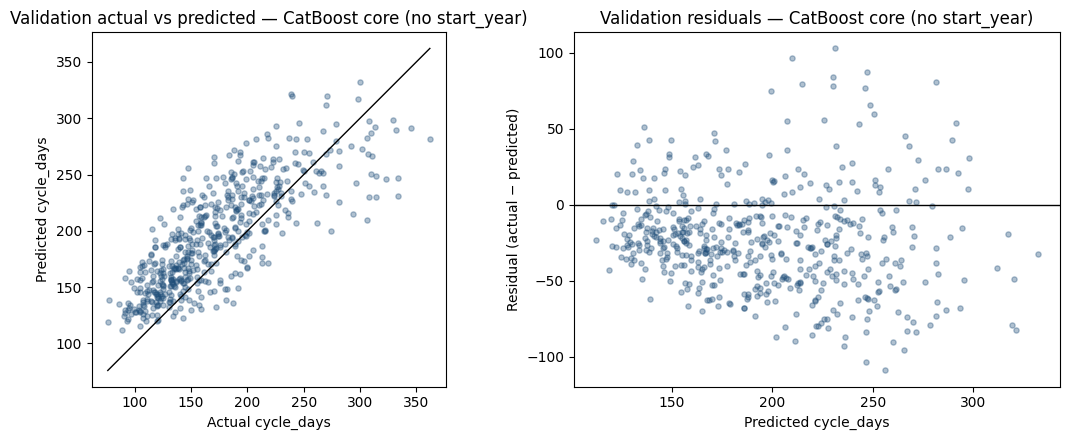

CatBoost core (no start_year) feature importance (PredictionValuesChange):


,feature,importance
0,is_spec_home,15.06
1,sqft,13.24
2,baths,9.61
3,community,8.51
4,product_line,7.70
5,basement_type,6.84
6,start_month,6.30
7,site_manager,5.93
8,start_quarter,5.27
9,lot_type,3.64


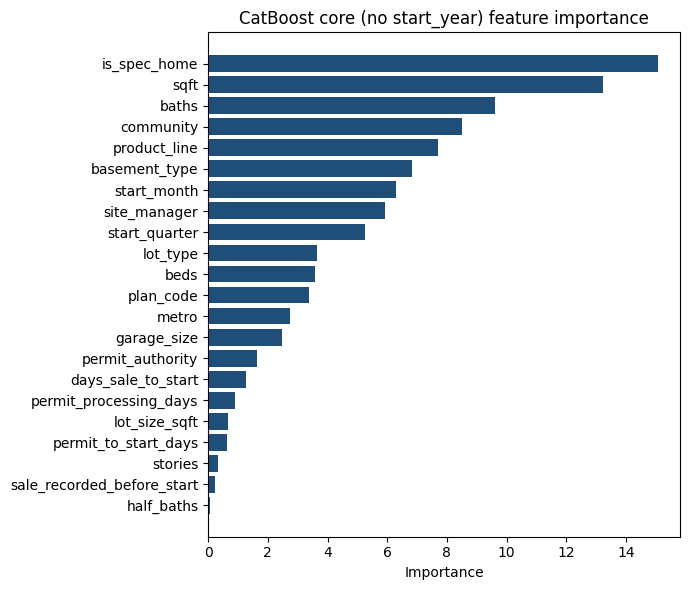

Note: a high importance for site_manager does not mean that manager causes faster or slower builds. It can stand in for community, crew mix, or how assignments are recorded.


In [9]:
pred_eligible = pred_core
eligible_name = "CatBoost core (no start_year)"

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
lo = min(y_val.min(), pred_eligible.min())
hi = max(y_val.max(), pred_eligible.max())
axes[0].scatter(y_val, pred_eligible, alpha=0.35, s=14, c="#1f4e79")
axes[0].plot([lo, hi], [lo, hi], color="black", linewidth=1)
axes[0].set_xlabel("Actual cycle_days")
axes[0].set_ylabel("Predicted cycle_days")
axes[0].set_title(f"Validation actual vs predicted — {eligible_name}")
axes[0].set_aspect("equal", adjustable="box")

resid = y_val.to_numpy() - pred_eligible
axes[1].scatter(pred_eligible, resid, alpha=0.35, s=14, c="#1f4e79")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("Predicted cycle_days")
axes[1].set_ylabel("Residual (actual − predicted)")
axes[1].set_title(f"Validation residuals — {eligible_name}")
fig.tight_layout()
plt.show()

imp = pd.DataFrame({
    "feature": cols_core,
    "importance": model_core.get_feature_importance(),
}).sort_values("importance", ascending=False)
print("CatBoost core (no start_year) feature importance (PredictionValuesChange):")
display(imp.reset_index(drop=True))

fig, ax = plt.subplots(figsize=(7, 6))
imp_plot = imp.sort_values("importance")
ax.barh(imp_plot.feature, imp_plot.importance, color="#1f4e79")
ax.set_xlabel("Importance")
ax.set_title("CatBoost core (no start_year) feature importance")
fig.tight_layout()
plt.show()

print(
    "Note: a high importance for site_manager does not mean that manager causes faster or slower builds. "
    "It can stand in for community, crew mix, or how assignments are recorded."
)


In [10]:
val_eval = val.copy()
val_eval["pred"] = pred_eligible
val_eval["abs_err"] = (val_eval["cycle_days"] - val_eval["pred"]).abs()
val_eval["resid"] = val_eval["cycle_days"] - val_eval["pred"]


def grouped_mae(frame, col):
    g = frame.groupby(col, dropna=False).agg(
        n=("cycle_days", "size"),
        actual_mean=("cycle_days", "mean"),
        pred_mean=("pred", "mean"),
        MAE=("abs_err", "mean"),
    )
    return g.sort_values("MAE", ascending=False)


print("MAE by construction-start year")
display(grouped_mae(val_eval, "start_year"))
print("MAE by metro")
display(grouped_mae(val_eval, "metro"))
print("MAE by product line")
display(grouped_mae(val_eval, "product_line"))
print("MAE by plan_code")
display(grouped_mae(val_eval, "plan_code"))

print("largest absolute errors (10 rows):")
display(
    val_eval.nlargest(10, "abs_err")[
        ["home_id", "construction_start_date", "metro", "product_line", "plan_code",
         "sqft", "cycle_days", "pred", "abs_err"]
    ]
)


MAE by construction-start year


,n,actual_mean,pred_mean,MAE
start_year,,,,
2024,530,172.62,195.28,33.20


MAE by metro


,n,actual_mean,pred_mean,MAE
metro,,,,
Calgary,199,176.72,201.14,34.78
Edmonton,152,164.20,186.12,33.28
Denver,179,175.20,196.55,31.36


MAE by product line


,n,actual_mean,pred_mean,MAE
product_line,,,,
Single Family,271,204.39,230.70,38.66
Duplex,86,157.65,180.05,32.88
Townhome,173,130.28,147.38,24.80


MAE by plan_code


,n,actual_mean,pred_mean,MAE
plan_code,,,,
SF-308,30,221.00,257.45,51.17
SF-309,37,238.00,265.95,45.56
SF-305,25,218.56,237.10,45.34
SF-302,26,174.38,210.52,38.28
SF-307,25,208.96,238.88,38.12
DX-202,30,156.63,180.48,36.92
SF-306,38,204.37,233.81,35.10
SF-304,30,201.87,218.64,34.34
DX-203,31,163.19,183.10,33.38


largest absolute errors (10 rows):


,home_id,construction_start_date,metro,product_line,plan_code,sqft,cycle_days,pred,abs_err
3350,H103354,2024-06-23,Calgary,Single Family,SF-309,3380,147,256.03,109.03
2935,H102939,2024-02-07,Edmonton,Single Family,SF-305,2580,143,246.70,103.70
2882,H102886,2024-01-22,Edmonton,Single Family,SF-308,3340,334,231.26,102.74
2961,H102965,2024-02-17,Denver,Duplex,DX-202,1630,306,209.53,96.47
3135,H103139,2024-04-14,Denver,Single Family,SF-309,3330,170,265.65,95.65
3051,H103055,2024-03-16,Denver,Single Family,SF-301,1900,143,235.82,92.82
3211,H103215,2024-05-07,Calgary,Single Family,SF-308,2950,170,260.21,90.21
3246,H103250,2024-05-19,Calgary,Single Family,SF-305,2580,122,211.36,89.36
3218,H103222,2024-05-11,Denver,Single Family,SF-308,3170,149,236.07,87.07
3333,H103337,2024-06-17,Denver,Single Family,SF-305,2730,334,246.99,87.01


## Site-manager performance analysis

The assignment asks which site managers deliver the fastest builds and how confident we are. This section does **not** answer that with CatBoost feature importance or with raw averages alone.

It is an **analytical comparison**, separate from model selection. It does **not** change the selected final specification (CatBoost core without `start_year` and without `selected_options_value`), the January–June 2024 validation metrics, the maturity cutoff, `04_final_predictions.ipynb`, or `predictions.csv`.

**Populations (same mature cohorts as above):**

| Cohort | Start dates | Role |
|---|---|---|
| Historical descriptive | 2021-01-01 through 2024-06-30 | Unadjusted manager summary |
| Risk-adjusted evaluation | January–June 2024 validation set | Residuals vs expected cycle time |

Starts after 2024-06-30 stay out because of completion-selection bias.


In [11]:
mature = pd.concat([train, val], axis=0, ignore_index=False)
assert (mature["construction_start_date"] >= TRAIN_START).all()
assert (mature["construction_start_date"] <= VAL_END).all()
assert not (mature["construction_start_date"] > VAL_END).any()
assert set(mature.index).isdisjoint(recent_excluded.index)
assert len(mature) == len(train) + len(val)

print("Historical descriptive cohort (train + Jan-Jun 2024 val)")
print("  rows:", len(mature))
print("  start min / max:", mature["construction_start_date"].min().date(),
      mature["construction_start_date"].max().date())
print("Risk-adjusted evaluation cohort (existing validation set)")
print("  rows:", len(val))
print("  start min / max:", val["construction_start_date"].min().date(),
      val["construction_start_date"].max().date())
print("excluded after 2024-06-30:", len(recent_excluded))

raw_sm = (
    mature.groupby("site_manager", dropna=False)
    .agg(
        n_completed_builds=("cycle_days", "size"),
        mean_cycle_days=("cycle_days", "mean"),
        median_cycle_days=("cycle_days", "median"),
        std_cycle_days=("cycle_days", "std"),
        p25_cycle_days=("cycle_days", lambda s: float(s.quantile(0.25))),
        p75_cycle_days=("cycle_days", lambda s: float(s.quantile(0.75))),
    )
    .reset_index()
    .sort_values(["mean_cycle_days", "site_manager"], ascending=[True, True])
    .reset_index(drop=True)
)
raw_sm["raw_rank"] = np.arange(1, len(raw_sm) + 1)

print()
print("Unadjusted site-manager comparison (mature starts through 2024-06-30)")
print("Sorted fastest to slowest by raw mean cycle_days. This is NOT a risk-adjusted ranking.")
display(raw_sm)

print(
    "Raw averages can mislead: managers are not randomly assigned and can differ in community, "
    "product line, floor plan, home size, and spec vs sold mix. A shorter raw mean may reflect "
    "an easier book of work rather than faster delivery."
)


Historical descriptive cohort (train + Jan-Jun 2024 val)
  rows: 3369
  start min / max: 2021-01-04 2024-06-28
Risk-adjusted evaluation cohort (existing validation set)
  rows: 530
  start min / max: 2024-01-01 2024-06-28
excluded after 2024-06-30: 708

Unadjusted site-manager comparison (mature starts through 2024-06-30)
Sorted fastest to slowest by raw mean cycle_days. This is NOT a risk-adjusted ranking.


,site_manager,n_completed_builds,mean_cycle_days,median_cycle_days,std_cycle_days,p25_cycle_days,p75_cycle_days,raw_rank
0,A. Boucher,158,177.85,173.00,52.00,137.00,208.00,1
1,C. Nakamura,196,178.91,172.00,53.64,138.75,214.25,2
2,D. Whitfield,203,179.51,174.00,50.08,144.50,210.00,3
3,F. Kowalski,180,180.52,167.00,58.20,137.75,212.25,4
4,E. Osei,193,182.38,168.00,61.34,140.00,211.00,5
5,J. Abadi,167,186.77,182.00,60.37,141.00,221.50,6
6,G. Ramirez,174,189.98,177.00,67.06,142.50,218.00,7
7,M. Petrov,195,192.84,181.00,65.99,137.00,240.00,8
8,P. Sandoval,171,194.60,184.00,67.01,142.50,233.00,9
9,K. Thibodeau,155,194.94,190.00,65.41,144.50,233.00,10


Raw averages can mislead: managers are not randomly assigned and can differ in community, product line, floor plan, home size, and spec vs sold mix. A shorter raw mean may reflect an easier book of work rather than faster delivery.


### Risk-adjusted comparison

An **auxiliary** CatBoost model predicts expected `cycle_days` from the same core start-time features as the selected model, **except `site_manager` is removed**. `start_year` and `selected_options_value` stay out.

It is fit on the 2021–2023 training cohort with the same hyperparameters and early-stopping rule as the validation models, using the January–June 2024 validation set only as `eval_set`. This model is **not** the final prediction model.

For each validation home:

`manager_residual_days = actual cycle_days − expected cycle_days`

- **Negative residual:** finished faster than expected for that project mix
- **Positive residual:** finished slower than expected
- **Near zero:** roughly matched expectation


In [12]:
FEATURES_SM_ADJ = [f for f in FEATURES_CORE_NO_YEAR if f != "site_manager"]
assert "site_manager" not in FEATURES_SM_ADJ
assert "start_year" not in FEATURES_SM_ADJ
assert "selected_options_value" not in FEATURES_SM_ADJ
assert FEATURES_SM_ADJ == [f for f in FEATURES_CORE_NO_YEAR if f != "site_manager"]

print("Auxiliary adjustment model — NOT the selected final prediction model.")
print("Features (core, no start_year, no selected_options_value, no site_manager):")
print(FEATURES_SM_ADJ)

model_sm_adj, pred_expected, info_sm_adj, cols_sm_adj = fit_catboost(
    FEATURES_SM_ADJ,
    "Auxiliary CatBoost (no site_manager; analytical adjustment only)",
)

assert cols_sm_adj == FEATURES_SM_ADJ
assert "site_manager" not in cols_sm_adj
assert "start_year" not in cols_sm_adj
assert "selected_options_value" not in cols_sm_adj
assert model_sm_adj is not model_core

val_sm = val.copy()
val_sm["expected_cycle_days"] = np.asarray(pred_expected, dtype=float)
val_sm["manager_residual_days"] = (
    val_sm["cycle_days"].astype(float) - val_sm["expected_cycle_days"]
)
assert val_sm["manager_residual_days"].notna().all()
assert np.isfinite(val_sm["manager_residual_days"].to_numpy()).all()

print("auxiliary validation MAE (not used for model selection):", round(float(info_sm_adj["MAE"]), 2))
print("validation residual mean / median:",
      round(float(val_sm["manager_residual_days"].mean()), 2),
      round(float(val_sm["manager_residual_days"].median()), 2))
print("negative residual = faster than expected for the home's characteristics")


Auxiliary adjustment model — NOT the selected final prediction model.
Features (core, no start_year, no selected_options_value, no site_manager):
['community', 'metro', 'permit_authority', 'plan_code', 'product_line', 'basement_type', 'lot_type', 'is_spec_home', 'beds', 'baths', 'half_baths', 'sqft', 'stories', 'garage_size', 'lot_size_sqft', 'start_month', 'start_quarter', 'permit_processing_days', 'permit_to_start_days', 'sale_recorded_before_start', 'days_sale_to_start']


Auxiliary CatBoost (no site_manager; analytical adjustment only): best_iteration=81 tree_count=82
auxiliary validation MAE (not used for model selection): 34.04
validation residual mean / median: -23.15 -26.05
negative residual = faster than expected for the home's characteristics


### Manager-level adjusted results

January–June 2024 residuals are grouped by `site_manager`. The 95% interval and the probability that the mean residual is below zero come from **at least 2,000** bootstrap resamples of that manager’s validation homes (fixed seed). Managers with fewer than 20 validation builds are kept in the table and flagged as low-sample.


In [13]:
N_BOOT = 2000
LOW_SAMPLE_N = 20
rng = np.random.default_rng(RANDOM_SEED)

grouped = {
    m: g["manager_residual_days"].to_numpy(dtype=float)
    for m, g in val_sm.groupby("site_manager", dropna=False)
}
managers = list(grouped.keys())

boot_means = {m: np.empty(N_BOOT, dtype=float) for m in managers}
fastest_counts = {m: 0 for m in managers}

for b in range(N_BOOT):
    means_b = {}
    for m, arr in grouped.items():
        sample = rng.choice(arr, size=len(arr), replace=True)
        means_b[m] = float(sample.mean())
        boot_means[m][b] = means_b[m]
    fastest = min(means_b, key=means_b.get)
    fastest_counts[fastest] += 1

rows = []
for m, arr in grouped.items():
    actual = val_sm.loc[val_sm["site_manager"] == m, "cycle_days"].astype(float)
    expected = val_sm.loc[val_sm["site_manager"] == m, "expected_cycle_days"]
    bm = boot_means[m]
    ci_low, ci_high = np.percentile(bm, [2.5, 97.5])
    rows.append({
        "site_manager": m,
        "validation_build_count": int(len(arr)),
        "actual_mean_cycle_days": float(actual.mean()),
        "expected_mean_cycle_days": float(expected.mean()),
        "mean_adjusted_residual_days": float(arr.mean()),
        "median_adjusted_residual_days": float(np.median(arr)),
        "ci_95_low": float(ci_low),
        "ci_95_high": float(ci_high),
        "ci_95_mean_residual": f"[{ci_low:.2f}, {ci_high:.2f}]",
        "prob_mean_residual_below_zero": float((bm < 0).mean()),
        "probability_ranked_fastest": fastest_counts[m] / N_BOOT,
        "low_sample_warning": "low sample (n<20)" if len(arr) < LOW_SAMPLE_N else "",
    })

adj_sm = pd.DataFrame(rows)
adj_sm = adj_sm.sort_values(
    ["mean_adjusted_residual_days", "site_manager"], ascending=[True, True]
).reset_index(drop=True)
adj_sm["adjusted_rank"] = np.arange(1, len(adj_sm) + 1)

raw_rank_map = raw_sm.set_index("site_manager")["raw_rank"]
adj_sm["raw_rank_mature"] = adj_sm["site_manager"].map(raw_rank_map)

display_cols = [
    "site_manager",
    "validation_build_count",
    "actual_mean_cycle_days",
    "expected_mean_cycle_days",
    "mean_adjusted_residual_days",
    "median_adjusted_residual_days",
    "ci_95_mean_residual",
    "prob_mean_residual_below_zero",
    "probability_ranked_fastest",
    "adjusted_rank",
    "raw_rank_mature",
    "low_sample_warning",
]
print(
    f"Adjusted manager comparison on Jan-Jun 2024 validation homes "
    f"(bootstrap {N_BOOT:,} within-manager resamples, seed {RANDOM_SEED})."
)
print("Most negative mean residual is ranked fastest. Low-sample managers are not dropped.")
display(adj_sm[display_cols])

n_low = int((adj_sm["validation_build_count"] < LOW_SAMPLE_N).sum())
print(f"managers with validation n < {LOW_SAMPLE_N}: {n_low} of {len(adj_sm)}")


Adjusted manager comparison on Jan-Jun 2024 validation homes (bootstrap 2,000 within-manager resamples, seed 42).
Most negative mean residual is ranked fastest. Low-sample managers are not dropped.


,site_manager,validation_build_count,actual_mean_cycle_days,expected_mean_cycle_days,mean_adjusted_residual_days,median_adjusted_residual_days,ci_95_mean_residual,prob_mean_residual_below_zero,probability_ranked_fastest,adjusted_rank,raw_rank_mature,low_sample_warning
0,W. Halvorsen,44,191.14,236.47,-45.33,-45.54,"[-53.92, -36.63]",1.00,0.53,1,17,
1,T. Beaulieu,25,172.24,216.34,-44.10,-54.32,"[-58.26, -28.26]",1.00,0.47,2,16,
2,J. Abadi,29,150.52,178.89,-28.37,-25.42,"[-37.78, -19.62]",1.00,0.00,3,6,
3,F. Kowalski,36,149.53,177.52,-27.99,-28.85,"[-36.08, -20.55]",1.00,0.00,4,4,
4,K. Thibodeau,24,175.58,202.92,-27.34,-29.02,"[-37.94, -17.43]",1.00,0.00,5,10,
5,R. Ivanova,26,188.73,215.87,-27.14,-30.51,"[-37.44, -17.40]",1.00,0.00,6,13,
6,P. Sandoval,40,173.35,197.26,-23.91,-25.35,"[-33.18, -13.06]",1.00,0.00,7,9,
7,V. Okonkwo,38,197.53,221.42,-23.90,-33.25,"[-35.71, -10.71]",1.00,0.00,8,18,
8,L. Mwangi,32,172.12,195.79,-23.66,-28.83,"[-33.23, -13.38]",1.00,0.00,9,12,
9,N. Ferreira,18,192.22,213.41,-21.18,-19.07,"[-37.98, -4.31]",0.99,0.00,10,14,low sample (n<20)


managers with validation n < 20: 1 of 18


### Ranking confidence

On every bootstrap iteration, each manager’s resampled mean residual is computed and the manager with the most negative mean is recorded as fastest. `probability_ranked_fastest` is that share of iterations.

| Probability ranked fastest | Confidence in a number-one ranking |
|---|---|
| ≥ 80% | High |
| 50% up to but not including 80% | Moderate |
| < 50% | Low |

If leading managers have overlapping 95% intervals, or no manager has a strong probability of ranking first, the data do not support a confident single winner. In that case the result is a **leading group**, not a forced ranking.


Adjusted #1: W. Halvorsen
validation n: 44
mean residual days: -45.33
95% CI: [-53.92, -36.63]
P(ranked fastest): 0.5265 -> moderate confidence
leading group (P ranked fastest >= 5%): W. Halvorsen, T. Beaulieu
of those, 95% CI overlaps the leader: W. Halvorsen, T. Beaulieu
confident single winner: False


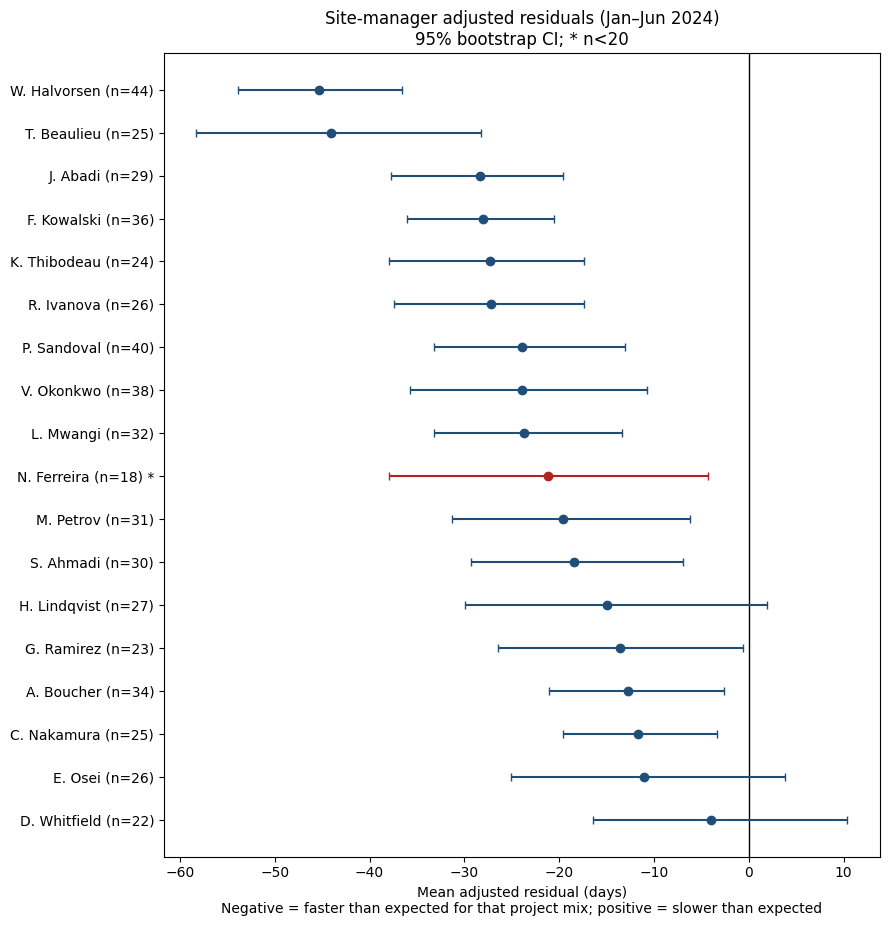

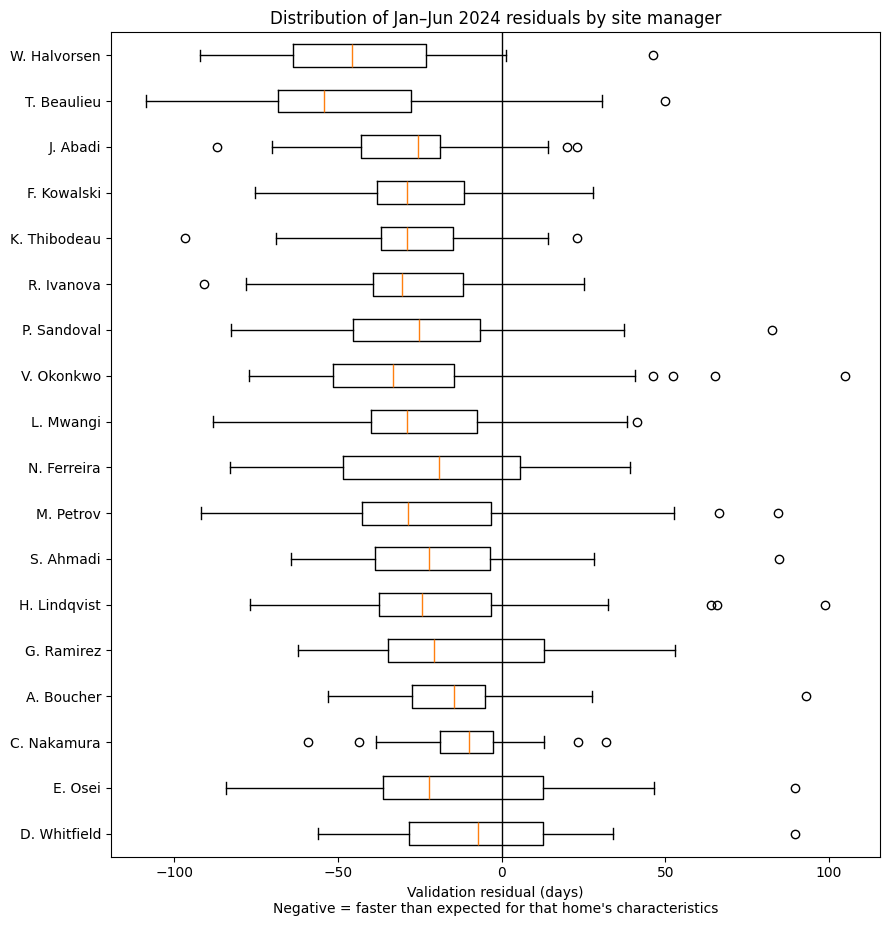

In [14]:
def rank_confidence(p):
    if p >= 0.80:
        return "high"
    if p >= 0.50:
        return "moderate"
    return "low"


leader = adj_sm.iloc[0]
p_first = float(leader["probability_ranked_fastest"])
leader_conf = rank_confidence(p_first)

# Leading group: managers who actually rank first in a non-trivial share of bootstraps.
# Pairwise CI overlap among everyone is too weak — small-n intervals overlap almost anyone.
leading_group = adj_sm.loc[adj_sm["probability_ranked_fastest"] >= 0.05].copy()
overlap_mask = (
    (leading_group["ci_95_low"] <= float(leader["ci_95_high"]))
    & (leading_group["ci_95_high"] >= float(leader["ci_95_low"]))
)
overlap_group = leading_group.loc[overlap_mask].copy()
if overlap_group.empty:
    overlap_group = leading_group.copy()
strong_first = p_first >= 0.80
confident_single_winner = bool(strong_first and len(overlap_group) == 1)

print("Adjusted #1:", leader["site_manager"])
print("validation n:", int(leader["validation_build_count"]))
print("mean residual days:", round(float(leader["mean_adjusted_residual_days"]), 2))
print("95% CI:", leader["ci_95_mean_residual"])
print("P(ranked fastest):", round(p_first, 4), "->", leader_conf, "confidence")
print("leading group (P ranked fastest >= 5%):", ", ".join(leading_group["site_manager"]))
print("of those, 95% CI overlaps the leader:", ", ".join(overlap_group["site_manager"]))
print("confident single winner:", confident_single_winner)

# Horizontal error-bar chart of adjusted mean residuals.
plot_df = adj_sm.sort_values("mean_adjusted_residual_days", ascending=True).copy()
y = np.arange(len(plot_df))
x = plot_df["mean_adjusted_residual_days"].to_numpy()
xerr = np.vstack([
    x - plot_df["ci_95_low"].to_numpy(),
    plot_df["ci_95_high"].to_numpy() - x,
])
colors = ["#b22222" if n < LOW_SAMPLE_N else "#1f4e79" for n in plot_df["validation_build_count"]]

fig, ax = plt.subplots(figsize=(9, 0.42 * len(plot_df) + 1.8))
ax.axvline(0, color="black", linewidth=1.0, zorder=0)
for i, (xi, lo, hi, col) in enumerate(zip(x, xerr[0], xerr[1], colors)):
    ax.errorbar(xi, i, xerr=[[lo], [hi]], fmt="o", color=col, capsize=3, markersize=6)
labels = []
for _, r in plot_df.iterrows():
    star = " *" if r["validation_build_count"] < LOW_SAMPLE_N else ""
    labels.append(f"{r['site_manager']} (n={int(r['validation_build_count'])}){star}")
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel(
    "Mean adjusted residual (days)\n"
    "Negative = faster than expected for that project mix; positive = slower than expected"
)
ax.set_title("Site-manager adjusted residuals (Jan–Jun 2024)\n95% bootstrap CI; * n<20")
fig.tight_layout()
plt.show()

# Boxplot of validation residuals by manager, same sort order.
fig2, ax2 = plt.subplots(figsize=(9, 0.42 * len(plot_df) + 1.8))
order_names = plot_df["site_manager"].tolist()
data = [grouped[m] for m in order_names]
ax2.boxplot(data, vert=False, tick_labels=order_names, showfliers=True)
ax2.axvline(0, color="black", linewidth=1.0)
ax2.invert_yaxis()
ax2.set_xlabel(
    "Validation residual (days)\n"
    "Negative = faster than expected for that home's characteristics"
)
ax2.set_title("Distribution of Jan–Jun 2024 residuals by site manager")
fig2.tight_layout()
plt.show()


### Written conclusion


In [15]:
fastest_days = -float(leader["mean_adjusted_residual_days"])
raw_leader = raw_sm.iloc[0]["site_manager"]
adj_leader_name = str(leader["site_manager"])
raw_rank_of_adj_leader = int(leader["raw_rank_mature"]) if pd.notna(leader["raw_rank_mature"]) else None
rank_differs = adj_leader_name != str(raw_leader)

if fastest_days >= 0:
    speed_phrase = f"{fastest_days:.1f} days faster than expected"
else:
    speed_phrase = f"{abs(fastest_days):.1f} days slower than expected"

if confident_single_winner:
    winner_sentence = (
        f"The data support naming **{adj_leader_name}** as the fastest manager on this "
        f"adjusted comparison, with **{leader_conf}** confidence in the number-one ranking."
    )
else:
    group_bits = ", ".join(
        f"**{r.site_manager}** ({float(r.probability_ranked_fastest):.1%} ranked fastest)"
        for r in overlap_group.itertuples()
    )
    winner_sentence = (
        f"The data **do not support a confident single winner**. "
        f"**{adj_leader_name}** has the lowest adjusted mean residual, but "
        f"{'leading managers have overlapping 95% confidence intervals' if len(overlap_group) > 1 else 'the probability of ranking first is not strong'}. "
        f"Treat them as a leading group rather than a definitive ranking: {group_bits}."
    )

if rank_differs:
    rank_sentence = (
        f"The adjusted ranking **differs** from the unadjusted ranking: "
        f"raw mean cycle time on the mature 2021–June 2024 cohort ranks **{raw_leader}** first, "
        f"while **{adj_leader_name}** is raw rank {raw_rank_of_adj_leader}."
    )
else:
    rank_sentence = (
        f"The adjusted #1 matches the unadjusted #1 (**{adj_leader_name}**), so the risk adjustment "
        f"does not change who looks fastest on mean cycle time, though the gap and confidence still "
        f"come from the residual analysis rather than from raw averages."
    )

low_n_note = ""
if int(leader["validation_build_count"]) < LOW_SAMPLE_N:
    low_n_note = (
        f" This leader has fewer than {LOW_SAMPLE_N} validation builds, so the estimate is noisy."
    )

text_sm = f"""
**Adjusted observational result (Jan–Jun 2024 validation).**
**{adj_leader_name}** has the lowest mean adjusted residual among site managers
({speed_phrase}; mean residual **{float(leader['mean_adjusted_residual_days']):.2f}** days)
on **{int(leader['validation_build_count'])}** validation builds.
95% bootstrap CI for the mean residual: **{leader['ci_95_mean_residual']}**.
Probability of ranking fastest: **{p_first:.1%}** ({leader_conf} confidence).
{winner_sentence}{low_n_note}

{rank_sentence}

This is an adjusted observational comparison, not a causal performance evaluation. Site-manager assignments are not random, and the estimates may still reflect unobserved differences in crews, workload, communities, project difficulty or data-recording practices.

Do not read this as evidence that a manager **causes** faster construction. The selected prediction model remains **CatBoost core without `start_year` and without `selected_options_value`**, which still includes `site_manager` as a categorical feature for scoring homes.
"""
display(Markdown(text_sm))

end_hash_sm = file_sha256(TRAIN_PATH)
print("training CSV sha256 unchanged after site-manager section:", end_hash_sm == RAW_HASH)
assert end_hash_sm == RAW_HASH, "Cleaned training CSV was modified; it must stay read-only."
assert not Path("predictions.csv").samefile(TRAIN_PATH)
print("Selected validation model object unchanged (model_core id):", id(model_core))
print("Auxiliary adjustment model is a separate object:", id(model_sm_adj) != id(model_core))



**Adjusted observational result (Jan–Jun 2024 validation).**
**W. Halvorsen** has the lowest mean adjusted residual among site managers
(45.3 days faster than expected; mean residual **-45.33** days)
on **44** validation builds.
95% bootstrap CI for the mean residual: **[-53.92, -36.63]**.
Probability of ranking fastest: **52.6%** (moderate confidence).
The data **do not support a confident single winner**. **W. Halvorsen** has the lowest adjusted mean residual, but leading managers have overlapping 95% confidence intervals. Treat them as a leading group rather than a definitive ranking: **W. Halvorsen** (52.6% ranked fastest), **T. Beaulieu** (46.8% ranked fastest).

The adjusted ranking **differs** from the unadjusted ranking: raw mean cycle time on the mature 2021–June 2024 cohort ranks **A. Boucher** first, while **W. Halvorsen** is raw rank 17.

This is an adjusted observational comparison, not a causal performance evaluation. Site-manager assignments are not random, and the estimates may still reflect unobserved differences in crews, workload, communities, project difficulty or data-recording practices.

Do not read this as evidence that a manager **causes** faster construction. The selected prediction model remains **CatBoost core without `start_year` and without `selected_options_value`**, which still includes `site_manager` as a categorical feature for scoring homes.


training CSV sha256 unchanged after site-manager section: True
Selected validation model object unchanged (model_core id): 2406960180480
Auxiliary adjustment model is a separate object: True


## 8. Interpretation and proposed choice

Metrics below are from the **January–June 2024** mature validation window. The recent excluded cohort is not used to pick a model. Shorter cycles in that excluded slice are **not** proof that construction got faster: those rows are only the jobs that finished in time to appear in the completed-only training CSV.


In [16]:
core_mae = float(info_core["MAE"])
year_mae = float(info_core_year["MAE"])
exp_mae = float(info_exp["MAE"])
g_mae = float(metrics(y_val, pred_global, "_")["MAE"])
p_mae = float(metrics(y_val, pred_plan, "_")["MAE"])
core_beats_both = (core_mae < g_mae) and (core_mae < p_mae)
year_helps = year_mae < core_mae
exp_helps = exp_mae < core_mae

by_year = grouped_mae(val_eval, "start_year")
by_metro = grouped_mae(val_eval, "metro")
by_prod = grouped_mae(val_eval, "product_line")
worst_year = str(by_year.index[0])
worst_metro = str(by_metro.index[0])
worst_prod = str(by_prod.index[0])
top_feat = imp.iloc[0]["feature"]

text = f'''
**Does CatBoost still beat both baselines?** {"Yes" if core_beats_both else "Not clearly"}.
Primary core (no `start_year`) MAE is **{core_mae:.2f}** days vs global-average **{g_mae:.2f}**
({(g_mae - core_mae) / g_mae * 100:.1f}% change) and vs floor-plan-average **{p_mae:.2f}**
({(p_mae - core_mae) / p_mae * 100:.1f}% change). RMSE / R2: {info_core["RMSE"]:.2f} / {info_core["R2"]:.3f}.

**Does `start_year` improve mature-period validation?** {"Yes, MAE falls to " + f"{year_mae:.2f}" if year_helps else "No stable gain; MAE is " + f"{year_mae:.2f} vs primary " + f"{core_mae:.2f}"}.
It is not retained automatically from earlier feature importance. On the old 80/20 split it likely absorbed snapshot / right-censoring effects in late 2024-2025 completes.

**Does `selected_options_value` improve performance?** {"Yes, expanded MAE is " + f"{exp_mae:.2f}" if exp_helps else "No; expanded MAE is " + f"{exp_mae:.2f} vs primary " + f"{core_mae:.2f}"}.
That is not sufficient to adopt it. Use the expanded spec only if the business confirms the export is the contracted amount known on the construction start date.

**Error patterns (Jan-Jun 2024 validation).** Actual mean {y_val.mean():.1f} days vs training {y_train.mean():.1f}.
Highest grouped MAE: start year **{worst_year}**, metro **{worst_metro}**, product line **{worst_prod}**.
Importance (primary model) is led by **{top_feat}**. That is not a causal claim. `site_manager` must not be read as proof that a named manager is faster or slower.

**Excluded recent cohort.** {len(recent_excluded)} completed rows start after 2024-06-30 (mean cycle {recent_excluded["cycle_days"].mean():.1f} days). They were not used for fitting, early stopping, baselines, or selection. Their shorter cycles are consistent with completion-selection bias before the 2025-07-31 snapshot, not with a finding that construction sped up.

**Proposed model for the next stage (pending review):** **CatBoost core without `start_year`**.
It uses start-time fields only, {"beats" if core_beats_both else "is compared against"} both baselines on a mature validation window, omits a year feature that previously tracked snapshot bias, and omits the unconfirmed options field.
Assumptions: Jan-Jun 2024 starts had enough elapsed time by 2025-07-31 for typical cycles to be observed; early stopping on this one window is acceptable for review; hyperparameters were not grid-searched.

Next step after approval: retrain the chosen spec on the mature training rows and score `homes_to_predict`. That is **not** done in this notebook.
'''
display(Markdown(text))

end_hash = file_sha256(TRAIN_PATH)
print("training CSV sha256 unchanged:", end_hash == RAW_HASH)
assert end_hash == RAW_HASH, "Cleaned training CSV was modified; it must stay read-only."



**Does CatBoost still beat both baselines?** Yes.
Primary core (no `start_year`) MAE is **33.20** days vs global-average **50.73**
(34.6% change) and vs floor-plan-average **36.81**
(9.8% change). RMSE / R2: 39.99 / 0.447.

**Does `start_year` improve mature-period validation?** No stable gain; MAE is 35.49 vs primary 33.20.
It is not retained automatically from earlier feature importance. On the old 80/20 split it likely absorbed snapshot / right-censoring effects in late 2024-2025 completes.

**Does `selected_options_value` improve performance?** Yes, expanded MAE is 31.71.
That is not sufficient to adopt it. Use the expanded spec only if the business confirms the export is the contracted amount known on the construction start date.

**Error patterns (Jan-Jun 2024 validation).** Actual mean 172.6 days vs training 199.3.
Highest grouped MAE: start year **2024**, metro **Calgary**, product line **Single Family**.
Importance (primary model) is led by **is_spec_home**. That is not a causal claim. `site_manager` must not be read as proof that a named manager is faster or slower.

**Excluded recent cohort.** 708 completed rows start after 2024-06-30 (mean cycle 151.7 days). They were not used for fitting, early stopping, baselines, or selection. Their shorter cycles are consistent with completion-selection bias before the 2025-07-31 snapshot, not with a finding that construction sped up.

**Proposed model for the next stage (pending review):** **CatBoost core without `start_year`**.
It uses start-time fields only, beats both baselines on a mature validation window, omits a year feature that previously tracked snapshot bias, and omits the unconfirmed options field.
Assumptions: Jan-Jun 2024 starts had enough elapsed time by 2025-07-31 for typical cycles to be observed; early stopping on this one window is acceptable for review; hyperparameters were not grid-searched.

Next step after approval: retrain the chosen spec on the mature training rows and score `homes_to_predict`. That is **not** done in this notebook.


training CSV sha256 unchanged: True
